## Data Collection and Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/telco-customer.csv')

## Basic Data Inspection & Overview

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

**Dataset Description (Telco Customer Churn)**

- customerID: รหัสประจำตัวลูกค้าแต่ละราย ใช้ระบุตัวตนของลูกค้า (Unique ID)
- gender: เพศของลูกค้า (Male, Female)
- SeniorCitizen: ลูกค้าเป็นผู้สูงอายุหรือไม่ (`1` = ใช่, `0` = ไม่ใช่)
- Partner: ลูกค้ามีคู่สมรสหรือคู่ชีวิตหรือไม่ (`Yes` = มี, `No` = ไม่มี)
- Dependents: ลูกค้ามีผู้ที่ต้องดูแล (บุตรหรือสมาชิกในครอบครัว) หรือไม่ (`Yes` = มี, `No` = ไม่มี)
- tenure: ระยะเวลาที่ลูกค้าใช้บริการกับบริษัท (หน่วยเป็นเดือน)
- PhoneService: ลูกค้าใช้บริการโทรศัพท์หรือไม่ (`Yes` = ใช้, No` = ไม่ใช้)
- MultipleLines: ลูกค้ามีหมายเลขโทรศัพท์หลายสายหรือไม่ (`Yes` = มีหลายสาย, `No` = มีสายเดียว, `No phone service` = ไม่มีบริการโทรศัพท์)
- InternetService: ประเภทบริการอินเทอร์เน็ตที่ลูกค้าใช้ (`DSL`, `Fiber optic`, `No`)
- OnlineSecurity: มีบริการรักษาความปลอดภัยออนไลน์หรือไม่ (`Yes`, `No`, `No internet service`)
- OnlineBackup: มีบริการสำรองข้อมูลออนไลน์หรือไม่ (`Yes`, `No`, `No internet service`)
- DeviceProtection: มีบริการป้องกันอุปกรณ์หรือไม่ (`Yes`, `No`, `No internet service`)
- TechSupport: มีบริการสนับสนุนทางเทคนิคหรือไม่ (`Yes`, `No`, `No internet service`)
- StreamingTV: มีบริการรับชมทีวีผ่านอินเทอร์เน็ตหรือไม่ (`Yes`, `No`, `No internet service`)
- StreamingMovies: มีบริการรับชมภาพยนตร์ผ่านอินเทอร์เน็ตหรือไม่ (`Yes`, `No`, `No internet service`)
- Contract: ประเภทสัญญาของลูกค้า (`Month-to-month` : รายเดือน, `One year` : รายปี, `Two year` : สองปี)
- PaperlessBilling: ลูกค้าเลือกใช้ใบแจ้งหนี้แบบอิเล็กทรอนิกส์หรือไม่ (`Yes` = ใช้ ,`No` = รับใบแจ้งหนี้แบบกระดาษ)
- PaymentMethod: วิธีการชำระเงิน
    - `Electronic check`
    - `Mailed check`
    - `Bank transfer (automatic)`
    - `Credit card (automatic)`
- MonthlyCharges: ค่าใช้จ่ายรายเดือนของลูกค้า (หน่วยเป็นดอลลาร์)
- TotalCharges: ค่าใช้จ่ายสะสมทั้งหมดตั้งแต่เริ่มใช้บริการจนถึงปัจจุบัน (หน่วยเป็นดอลลาร์)
- Churn (Target Variable): ลูกค้าเลิกใช้บริการหรือไม่ (`Yes` = ลูกค้าเลิกใช้บริการ, `No` = ลูกค้ายังคงใช้บริการ)

## Data Cleaning

### Correct Data Types

In [8]:
df['SeniorCitizen'] = (df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category'))

In [9]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]

df[cat_cols] = df[cat_cols].astype('category')

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.dtypes

customerID               str
gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

### Handle Missing Values

In [12]:
df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Remove Duplicates

In [15]:
df.duplicated().sum()

np.int64(0)

### Drop Irrelevant Columns

In [16]:
df.drop(columns=['customerID'], inplace=True)

In [17]:
df.dtypes

gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

## Univariate Analysis

### Target Variables

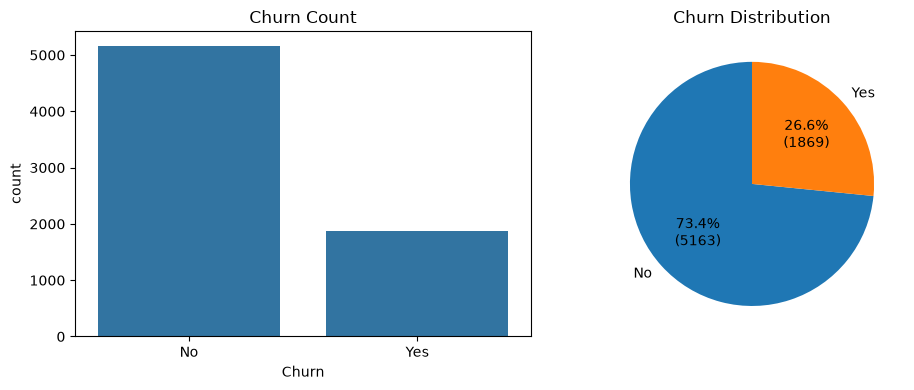

In [18]:
target = 'Churn'
counts = df[target].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x=target, ax=axes[0])
axes[0].set_title('Churn Count')
axes[1].pie(counts, labels=counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*counts.sum())})',
    startangle=90
)
axes[1].set_title('Churn Distribution')
plt.tight_layout()
plt.show()

### Numerical Variables

In [19]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


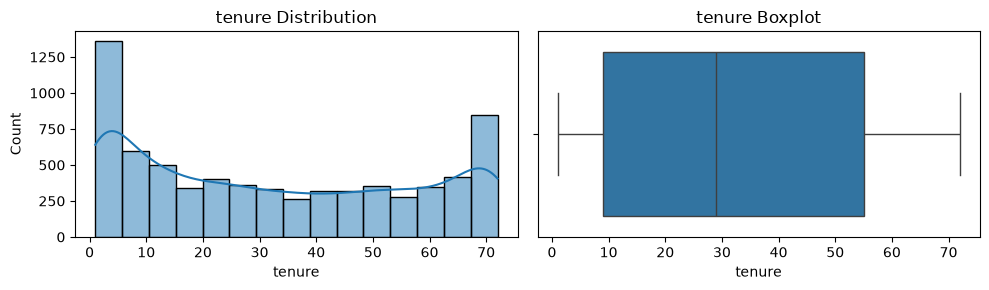

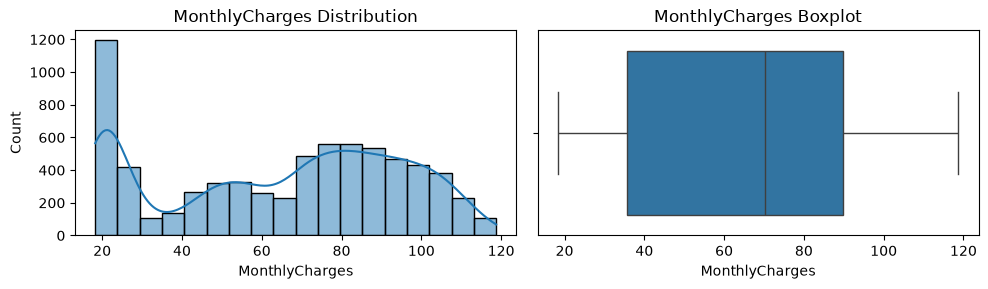

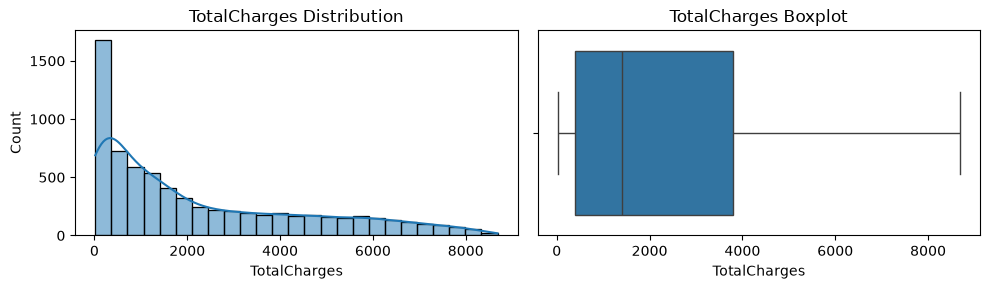

In [20]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')
    plt.tight_layout()
    plt.show()

### Categorical Variables

In [21]:
df.describe(include=['category']).T

,count,unique,top,freq
gender,7032,2,Male,3549
SeniorCitizen,7032,2,No,5890
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094


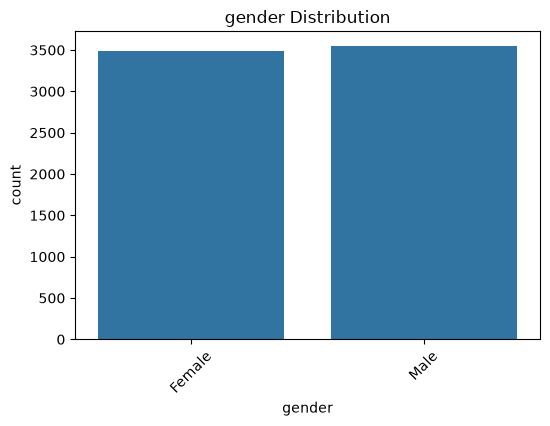

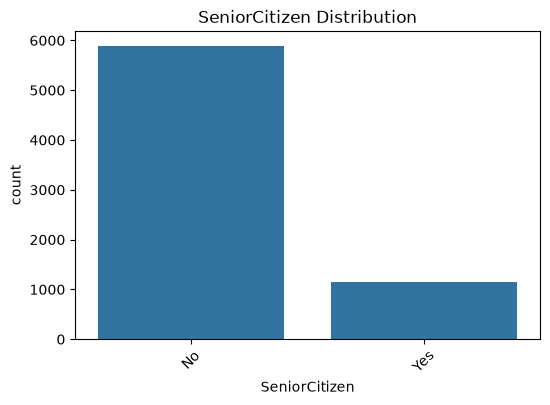

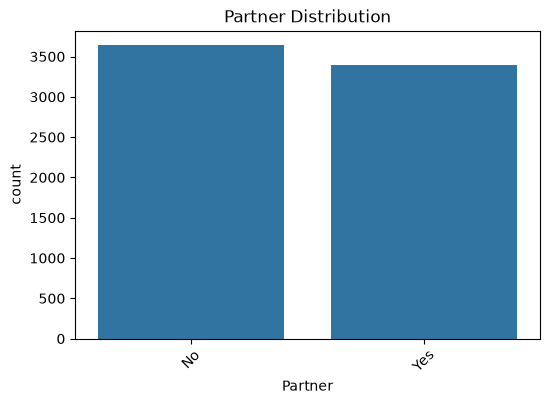

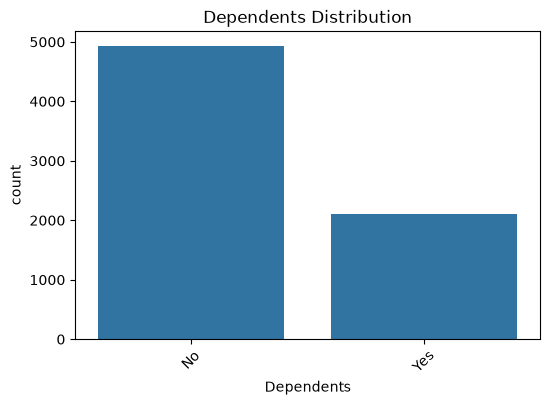

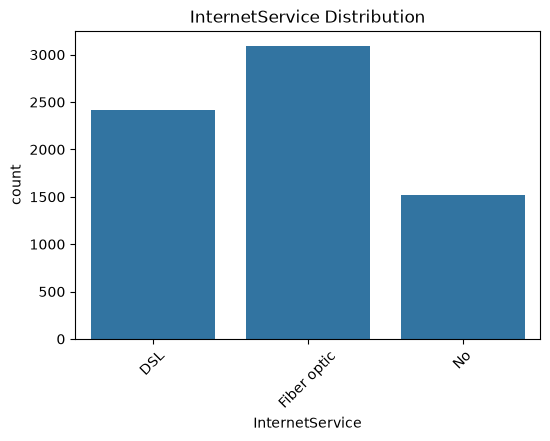

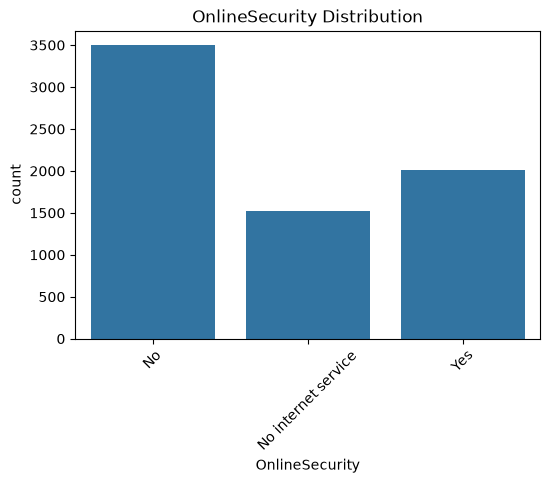

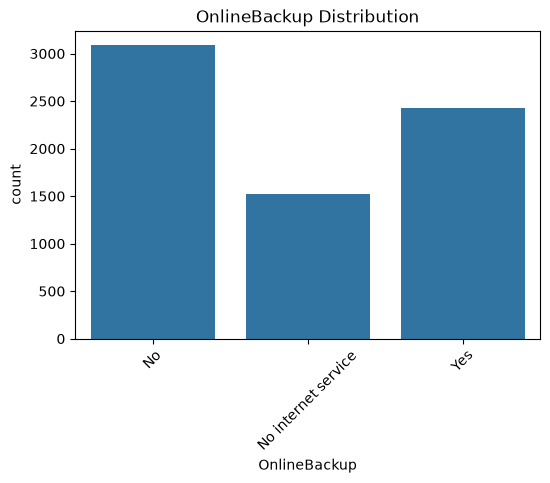

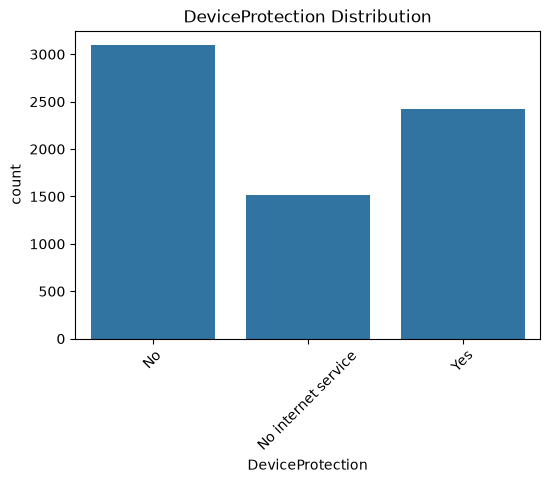

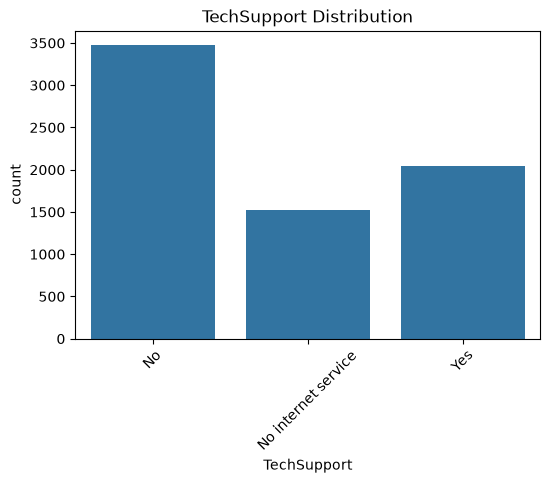

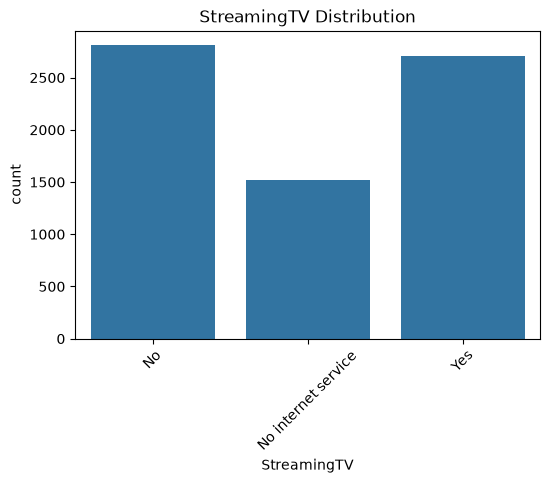

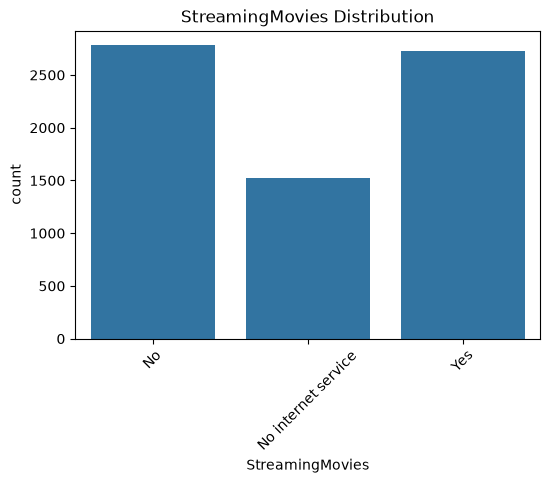

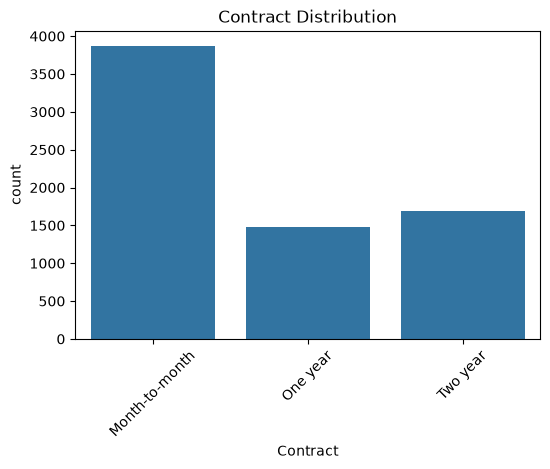

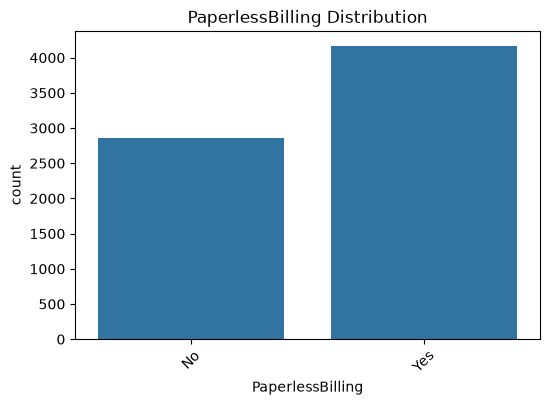

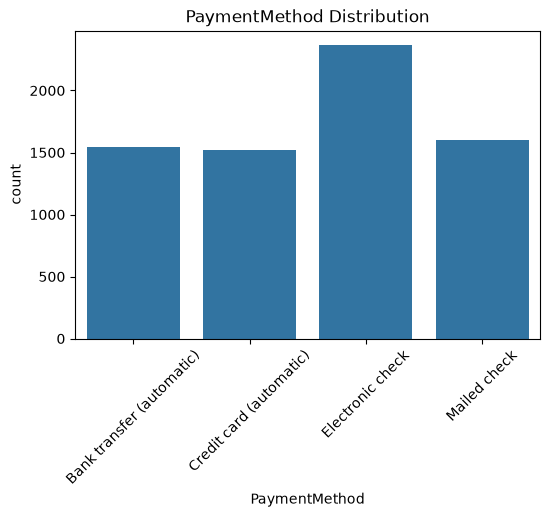

In [22]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

## Bivariate Analysis

### Numerical vs. Numerical

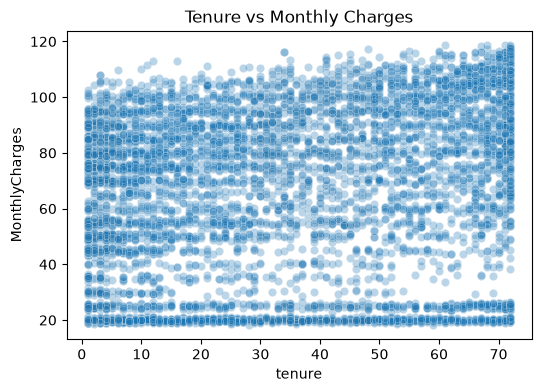

In [23]:
# ดูว่าลูกค้าที่ใช้งานนานขึ้นมีค่าใช้จ่ายรายเดือนสูงขึ้นหรือไม่
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', alpha=0.3)
plt.title('Tenure vs Monthly Charges')
plt.show()

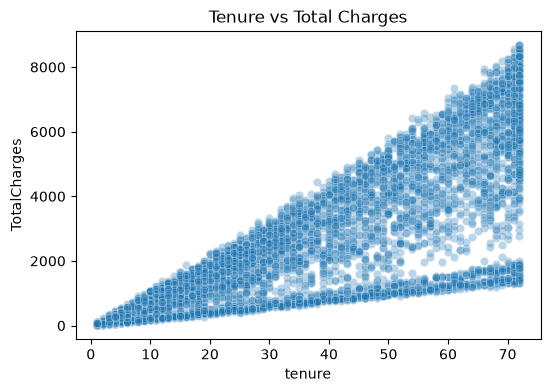

In [24]:
# คาดว่าจะมีความสัมพันธ์เชิงบวกชัดเจน เพราะ TotalCharges สะสมตามระยะเวลาใช้งาน
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', alpha=0.3)
plt.title('Tenure vs Total Charges')
plt.show()

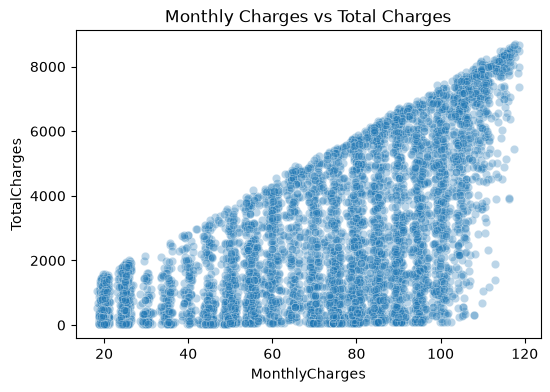

In [25]:
# ดูว่าค่าบริการรายเดือนสัมพันธ์กับยอดรวมทั้งหมดอย่างไร
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', alpha=0.3)
plt.title('Monthly Charges vs Total Charges')
plt.show()

### Categorical vs. Numerical

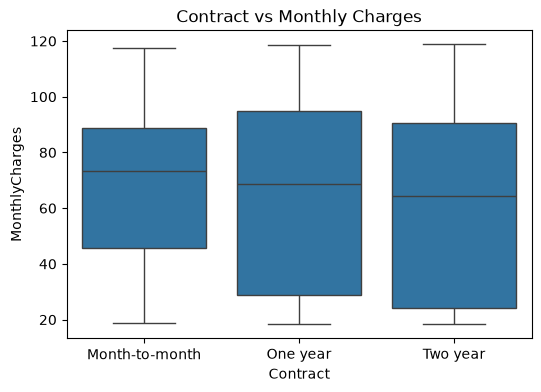

In [26]:
# เปรียบเทียบค่าบริการรายเดือนของแต่ละประเภทสัญญา
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges')
plt.title('Contract vs Monthly Charges')
plt.show()

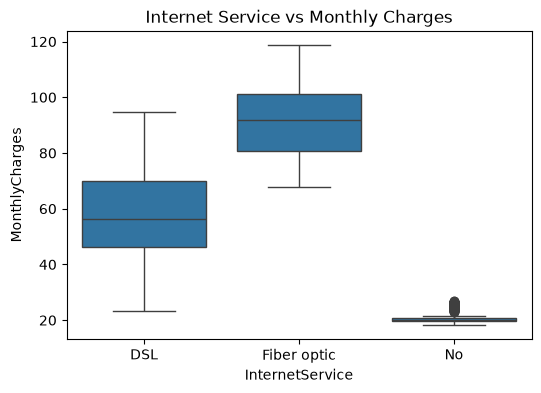

In [27]:
# ดูว่า Fiber optic, DSL และ No internet service มีค่าใช้จ่ายต่างกันอย่างไร
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges')
plt.title('Internet Service vs Monthly Charges')
plt.show()

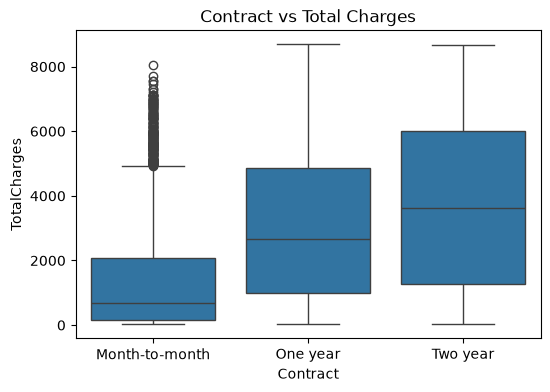

In [28]:
# เปรียบเทียบยอดรวมของลูกค้าแต่ละประเภทสัญญา
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Contract', y='TotalCharges')
plt.title('Contract vs Total Charges')
plt.show()

### Categorical vs. Categorical

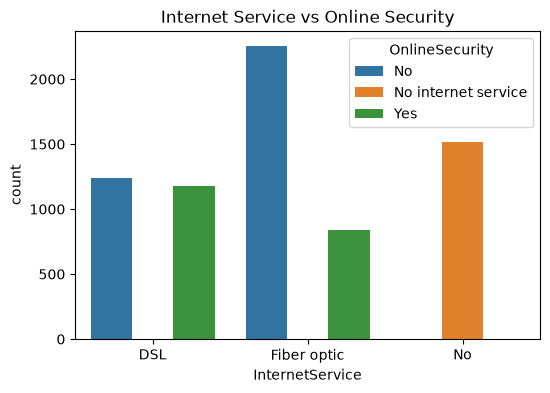

In [29]:
# ดูความสัมพันธ์ระหว่างประเภทอินเทอร์เน็ตกับบริการเสริม
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='OnlineSecurity')
plt.title('Internet Service vs Online Security')
plt.show()

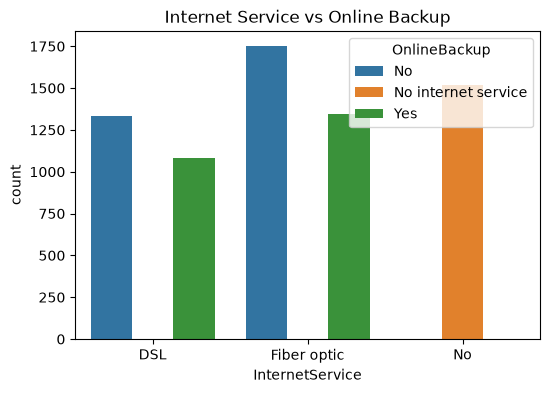

In [30]:
# ดูความสัมพันธ์ระหว่างประเภทอินเทอร์เน็ตกับบริการเสริม
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='OnlineBackup')
plt.title('Internet Service vs Online Backup')
plt.show()

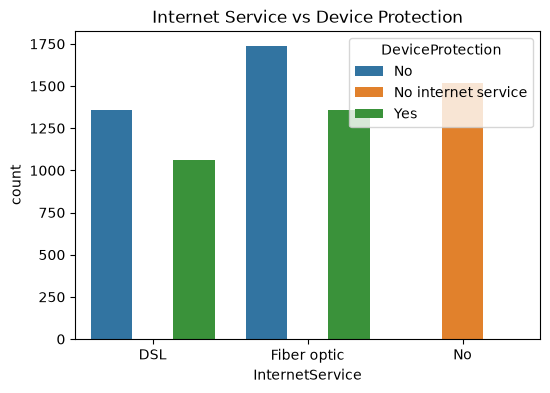

In [31]:
# ดูความสัมพันธ์ระหว่างประเภทอินเทอร์เน็ตกับบริการเสริม
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='DeviceProtection')
plt.title('Internet Service vs Device Protection')
plt.show()

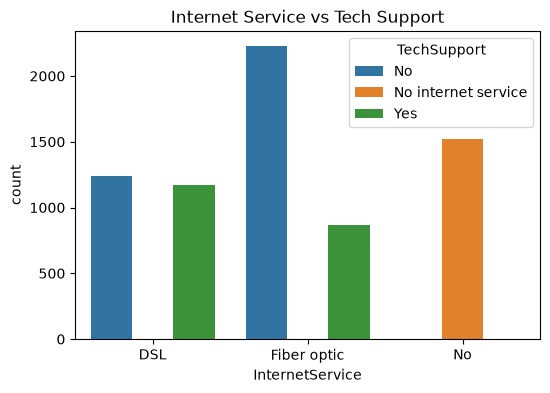

In [32]:
# ดูความสัมพันธ์ระหว่างประเภทอินเทอร์เน็ตกับบริการเสริม
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='TechSupport')
plt.title('Internet Service vs Tech Support')
plt.show()

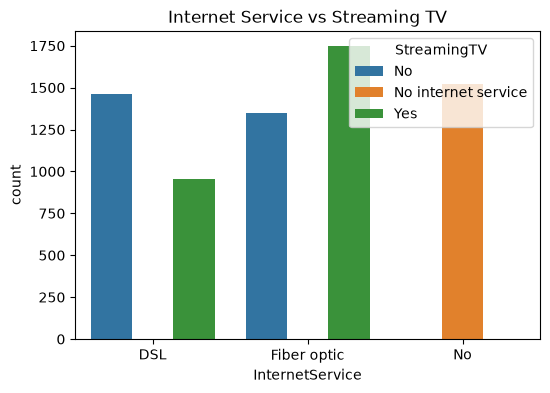

In [33]:
# ดูความสัมพันธ์ระหว่างประเภทอินเทอร์เน็ตกับบริการเสริม
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='StreamingTV')
plt.title('Internet Service vs Streaming TV')
plt.show()

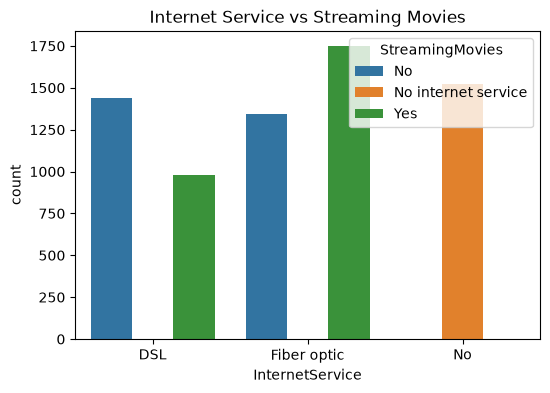

In [34]:
# ดูความสัมพันธ์ระหว่างประเภทอินเทอร์เน็ตกับบริการเสริม
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='StreamingMovies')
plt.title('Internet Service vs Streaming Movies')
plt.show()

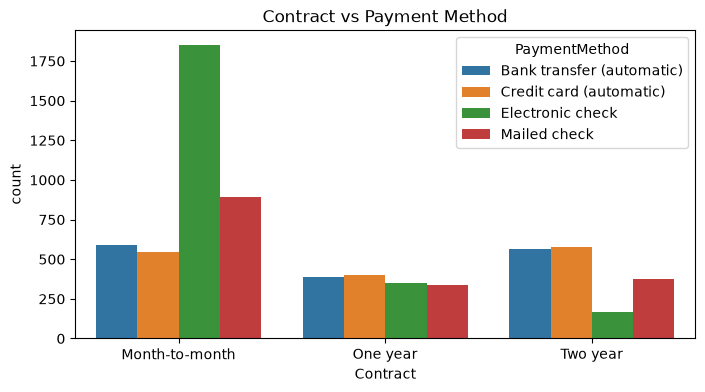

In [35]:
# ดูวิธีชำระเงินในแต่ละสัญญา
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='PaymentMethod')
plt.title('Contract vs Payment Method')
plt.show()

### Variables vs Target

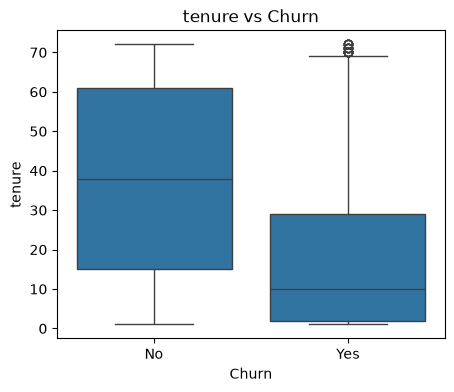

In [36]:
# เปรียบเทียบการกระจายของอายุการใช้งานระหว่าง Churn/No Churn
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('tenure vs Churn')
plt.show()

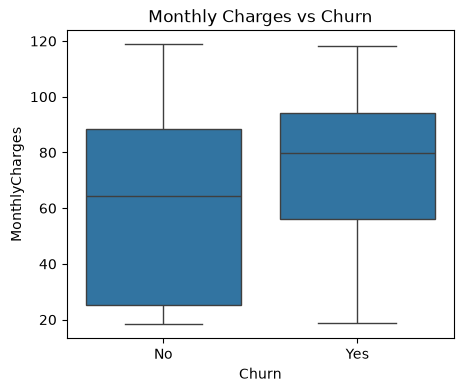

In [37]:
# ดูว่าผู้ที่ Churn มีค่าใช้จ่ายสูงกว่าหรือไม่
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

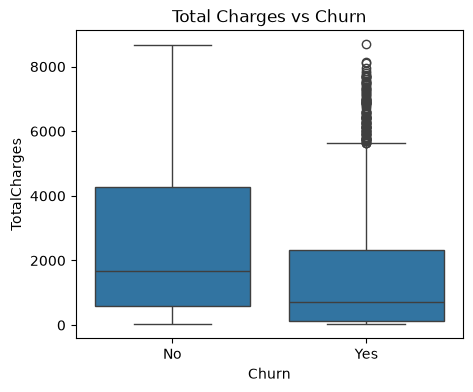

In [38]:
# เปรียบเทียบยอดรวมระหว่างสองกลุ่ม
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges vs Churn')
plt.show()

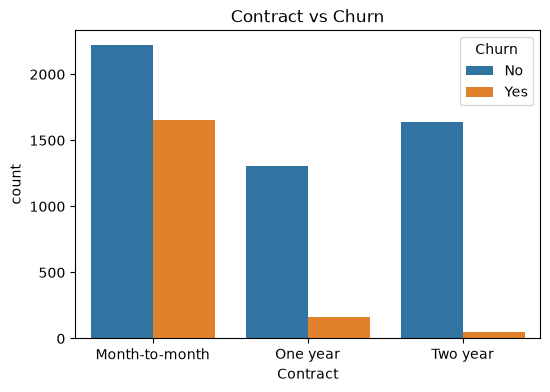

In [39]:
# ประเภทสัญญามักมีผลต่อการยกเลิกบริการโดยตรง
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract vs Churn')
plt.show()

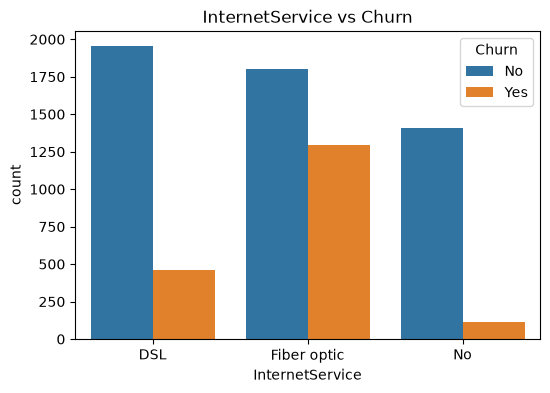

In [40]:
# Fiber optic, DSL และ No internet service อาจมีอัตรา Churn ต่างกันมาก
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('InternetService vs Churn')
plt.show()

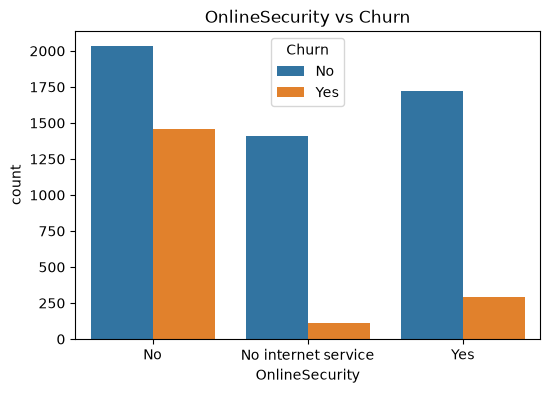

In [41]:
# ลูกค้าที่ไม่มี OnlineSecurity อาจ Churn สูงกว่า
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('OnlineSecurity vs Churn')
plt.show()

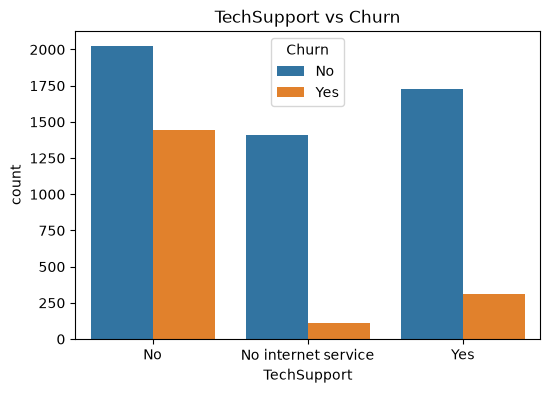

In [42]:
# การมีบริการช่วยเหลืออาจทำให้ลูกค้าอยู่ต่อ
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('TechSupport vs Churn')
plt.show()

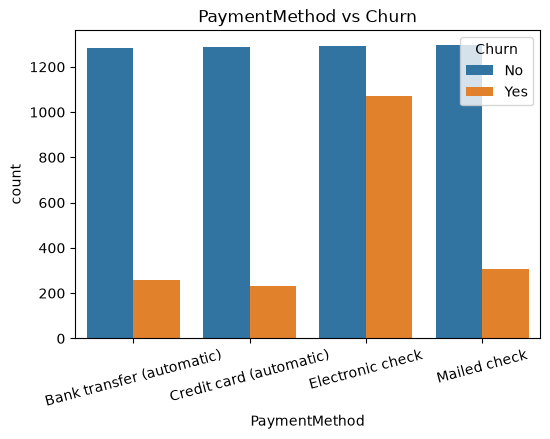

In [43]:
# Electronic check มักมีอัตรา Churn สูงกว่า
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=15)
plt.title('PaymentMethod vs Churn')
plt.show()

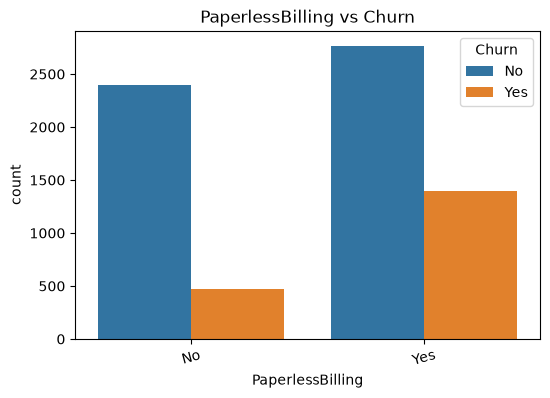

In [44]:
# มีความสัมพันธ์กับรูปแบบการใช้งานและการชำระเงิน
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.xticks(rotation=15)
plt.title('PaperlessBilling vs Churn')
plt.show()

## Multivariate Analysis

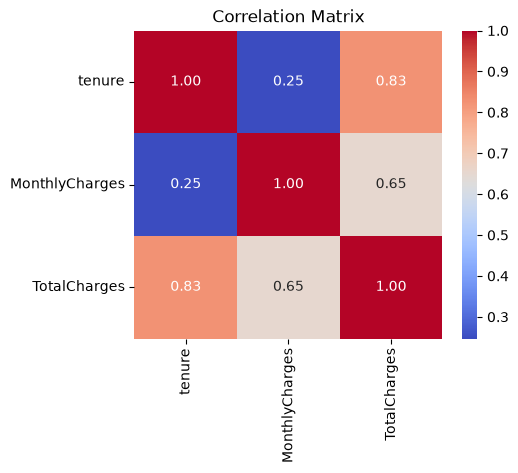

In [45]:
num_corr = df[num_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.show()

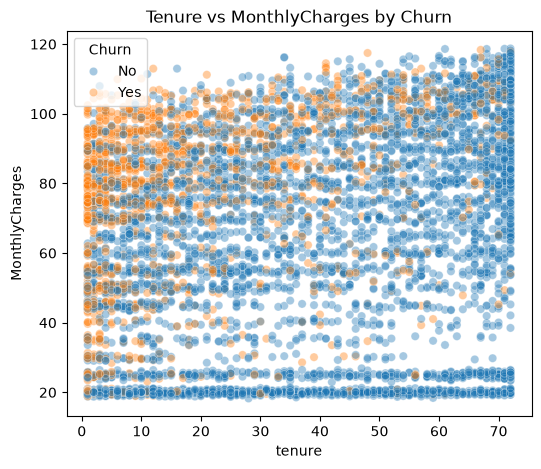

In [46]:
# ลูกค้าใหม่ + ค่าใช้จ่ายสูง อาจมีแนวโน้ม Churn สูง
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4)
plt.title('Tenure vs MonthlyCharges by Churn')
plt.show()

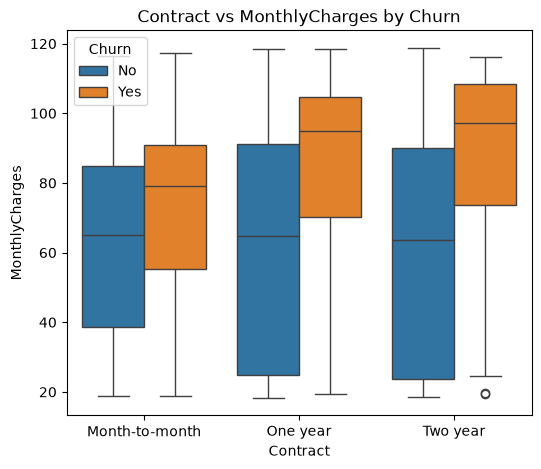

In [47]:
# Month-to-month ที่ค่าใช้จ่ายสูงอาจ Churn มากที่สุด
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges',hue='Churn')
plt.title('Contract vs MonthlyCharges by Churn')
plt.show()

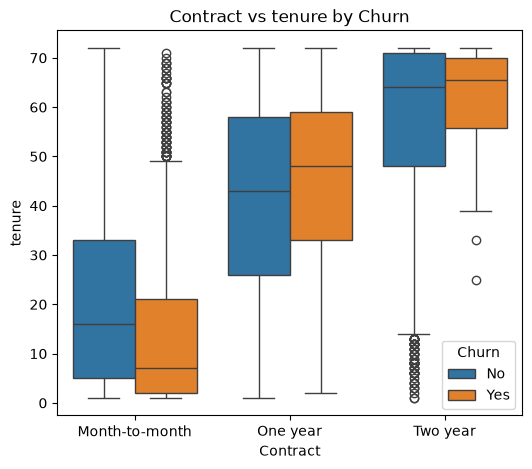

In [48]:
# ลูกค้า Month-to-month ที่ใช้งานไม่นานอาจยกเลิกมากกว่า
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Contract', y='tenure',hue='Churn')
plt.title('Contract vs tenure by Churn')
plt.show()

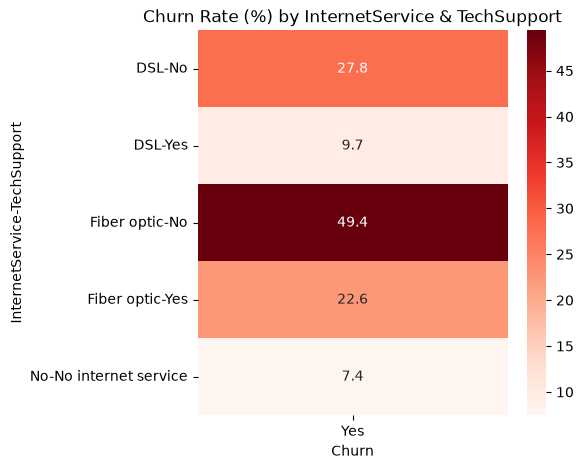

In [49]:
# ลูกค้าที่ไม่มี TechSupport อาจ Churn สูง
cross = pd.crosstab([df['InternetService'], df['TechSupport']], df['Churn'], normalize='index') * 100

plt.figure(figsize=(5,5))
sns.heatmap(cross[['Yes']], annot=True, fmt='.1f',cmap='Reds')
plt.title('Churn Rate (%) by InternetService & TechSupport')
plt.show()

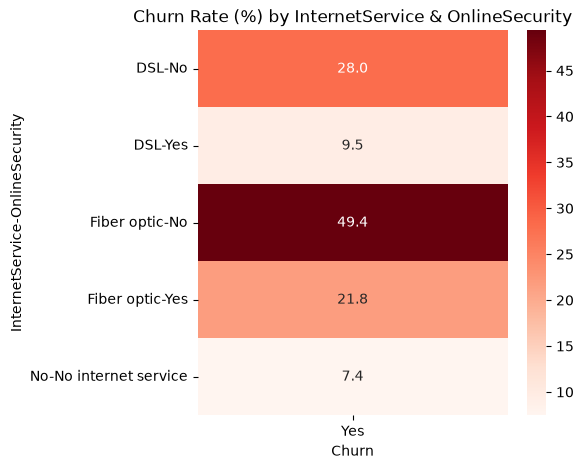

In [50]:
# ความปลอดภัยของบริการมีผลต่อการรักษาลูกค้า
cross = pd.crosstab([df['InternetService'], df['OnlineSecurity']], df['Churn'], normalize='index') * 100

plt.figure(figsize=(5,5))
sns.heatmap(cross[['Yes']], annot=True, fmt='.1f',cmap='Reds')
plt.title('Churn Rate (%) by InternetService & OnlineSecurity')
plt.show()

## Outlier Detection and Treatment

In [51]:
out_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in out_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {outliers.shape[0]}")


tenure
Lower bound: -60.00
Upper bound: 124.00
Number of outliers: 0

MonthlyCharges
Lower bound: -45.82
Upper bound: 171.27
Number of outliers: 0

TotalCharges
Lower bound: -4688.48
Upper bound: 8884.67
Number of outliers: 0


## Summary and Documentation

1. ภาพรวมชุดข้อมูล (Dataset Overview)
    - ข้อมูล: พฤติกรรมการยกเลิกบริการของลูกค้าเครือข่ายโทรคมนาคม (Telco Customer Churn) เริ่มต้นมีข้อมูล 7,043 แถว และ 21 คอลัมน์
    - ตัวแปรเป้าหมาย (Target Variable): Churn (ลูกค้าเลิกใช้บริการหรือไม่)

2. การทำความสะอาดข้อมูล (Data Cleaning & Missing Values)
    - การจัดการชนิดข้อมูล (Data Types): * แปลงข้อมูล SeniorCitizen จาก 0, 1 เป็น No, Yes
        - เปลี่ยนคอลัมน์ที่เป็นข้อความให้เป็นชนิดข้อมูลแบบหมวดหมู่ (Category)
        - แปลง TotalCharges จากข้อความให้เป็นตัวเลข (Numeric) ซึ่งทำให้พบค่าที่ผิดปกติหรือเว้นว่าง

    - ค่าสูญหาย (Missing Values): พบค่าว่างในคอลัมน์ TotalCharges จำนวน 11 แถว ซึ่งได้ถูกจัดการโดยการ ลบแถวที่มีค่าว่างทิ้ง (Dropna) ทำให้ข้อมูลพร้อมใช้งานเหลือ 7,032 แถว
    - ข้อมูลซ้ำ (Duplicates): ไม่พบข้อมูลซ้ำซ้อน (0 Duplicates)
    - คอลัมน์ที่ไม่ได้ใช้งาน: ทำการลบคอลัมน์ customerID ออกไปแล้ว เนื่องจากไม่ส่งผลต่อการทำนาย

3. การตรวจสอบค่าผิดปกติ (Outliers)
    - จากการตรวจสอบตัวแปรเชิงปริมาณ ได้แก่ tenure, MonthlyCharges และ TotalCharges ด้วยเทคนิค IQR (Interquartile Range) ไม่พบค่า Outliers ในข้อมูลชุดนี้ ทำให้สามารถนำตัวเลขไปใช้งานหรือทำ Scaling ต่อได้โดยไม่ต้องกังวลเรื่องค่าสุดโต่ง

4. ข้อมูลเชิงสถิติที่สำคัญ (เพื่อนำไปพิจารณาเลือกตัวแปร)
    - ข้อมูลตัวแปรเป้าหมาย (Churn): มีลูกค้าที่ยกเลิกบริการ (Yes) น้อยกว่าลูกค้าที่ยังใช้บริการต่อ (No = 5,163 คน) ข้อมูลนี้สะท้อนให้เห็นว่าชุดข้อมูลมีความไม่สมดุล (Imbalanced Dataset) ซึ่งหากนำไปสร้างโมเดลอาจต้องพิจารณาเทคนิค Resampling
    - ตัวแปรเชิงกลุ่ม (Categorical): * ลูกค้าส่วนใหญ่เลือกทำสัญญาแบบรายเดือน (Month-to-month) ซึ่งเป็นกลุ่มที่มักจะมีความเสี่ยงในการยกเลิกบริการสูงกว่าแบบรายปี
    - อินเทอร์เน็ตยอดนิยมคือ Fiber optic และวิธีชำระเงินส่วนใหญ่มักจะใช้ Electronic check
    - ตัวแปรเชิงปริมาณ (Numerical): ระยะเวลาใช้งาน (tenure) มีค่าเฉลี่ยที่ 32.4 เดือน โดยมีค่าสูงสุดถึง 72 เดือน

5. ความสัมพันธ์ของข้อมูล (Bivariate Analysis)
    - จากการพลอตกราฟเบื้องต้นพบว่ามีการวิเคราะห์ความสัมพันธ์ระหว่างการรับบิลแบบกระดาษ/อิเล็กทรอนิกส์ (PaperlessBilling) กับโอกาสในการยกเลิกบริการ (Churn) ซึ่งพฤติกรรมการจ่ายเงินและรูปแบบสัญญานี้น่าจะเป็น Feature (ตัวแปร) สำคัญที่ช่วยชี้วัดความน่าจะเป็นของการยกเลิกบริการได้